### Détection des anomalies structurelles

Objectif :
- repérer les événements dont la structure locale est inhabituelle
- produire un score d'anomalie structurelle
- générer une explication lisible pour chaque événement suspect

Entrétie principaleuspects_df` avec score, niveau d'alerte et motif

In [21]:
import json
import math
import hashlib
from pathlib import Path
from collections.abc import Mapping
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx


from IPython.display import display

sns.set_theme(style="whitegrid")

DATA_PATH = "data/export.events.json"
FIGURES_PATH = Path("figures")
FIGURES_PATH.mkdir(exist_ok=True)

# CHARGEMENT

with open(DATA_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)

print(f"Nombre d'événements chargés : {len(data)}")

Nombre d'événements chargés : 11948


In [8]:
import json
import pandas as pd

# ── Fichiers générés par ton collègue ──────────────────────────────────────
ANOMALIES_CSV      = "anomalies.csv"
QUASI_DOUBLONS_CSV = "quasi_doublons.csv"
EVENTS_CLUSTERING  = "events_clustering.json"   # contient cluster_id, is_noise, is_quasi_dup

# ── Chargement ─────────────────────────────────────────────────────────────
df_anom = pd.read_csv(ANOMALIES_CSV)
df_qd   = pd.read_csv(QUASI_DOUBLONS_CSV)

with open(EVENTS_CLUSTERING, encoding="utf-8") as f:
    ev_clust = json.load(f)

print(f"✅ anomalies.csv        : {len(df_anom)} lignes")
print(f"✅ quasi_doublons.csv   : {len(df_qd)} lignes")
print(f"✅ events_clustering    : {len(ev_clust)} events")
print()
print("Colonnes anomalies :", list(df_anom.columns))
print("Colonnes quasi_dup :", list(df_qd.columns))

In [9]:
event_rows = []

for i, ev in enumerate(data):
    created_at = parse_dt(ev.get("createdAt"))
    end_at = parse_dt(ev.get("endAt"))

    context = ev.get("context", "")
    nodes = ev.get("nodes", [])
    edges = ev.get("edges", [])

    event_rows.append({
        "event_id": unwrap_mongo_value(ev.get("_id")),
        "createdAt": created_at,
        "endAt": end_at,
        "type": ev.get("type"),
        "type_lvl1": simplify_taxonomy(ev.get("type"), 1),
        "type_lvl2": simplify_taxonomy(ev.get("type"), 2),
        "type_lvl3": simplify_taxonomy(ev.get("type"), 3),
        "type_last": simplify_taxonomy(ev.get("type"), None),
        "domain": ev.get("domain"),
        "domain_last": simplify_taxonomy(ev.get("domain"), None),
        "subdomain": ev.get("subdomain"),
        "subdomain_last": simplify_taxonomy(ev.get("subdomain"), None),
        "risk": ev.get("risk"),
        "risk_last": simplify_taxonomy(ev.get("risk"), None),
        "riskCarac": ev.get("riskCarac"),
        "riskCarac_last": simplify_taxonomy(ev.get("riskCarac"), None),
        "sourceNodeId": ev.get("sourceNodeId"),
        "resultAnalyseId": ev.get("resultAnalyseId"),
        "taskId": ev.get("taskId"),
        "context": context,
        "context_chars": len(context) if isinstance(context, str) else 0,
        "context_words": len(context.split()) if isinstance(context, str) else 0,
        "context_hash": hash_text(context),
        "n_nodes": len(nodes) if isinstance(nodes, list) else 0,
        "n_edges": len(edges) if isinstance(edges, list) else 0,
        "_class": ev.get("_class")
    })

events_df = pd.DataFrame(event_rows)

events_df["graph_density_directed"] = events_df.apply(
    lambda r: r["n_edges"] / (r["n_nodes"] * (r["n_nodes"] - 1))
    if r["n_nodes"] > 1 else 0,
    axis=1
)

events_df["edge_node_ratio"] = events_df.apply(
    lambda r: r["n_edges"] / r["n_nodes"] if r["n_nodes"] > 0 else np.nan,
    axis=1
)

events_df.head()

,event_id,createdAt,endAt,type,type_lvl1,type_lvl2,type_lvl3,type_last,domain,domain_last,...,taskId,context,context_chars,context_words,context_hash,n_nodes,n_edges,_class,graph_density_directed,edge_node_ratio
0,698b35e78f03efde04a87998,2026-02-10 13:43:03.827000+00:00,NaT,Thing/Abstract/Event/Win,Thing,Thing/Abstract,Thing/Abstract/Event,Win,NaN,NaN,...,1a076139-ea5e-40e2-8d82-01a1f28b8181,Portrait des six principaux candidats qui sont...,164,27,2e1b77de95e4c51fc56ea9b066f1239a,3,2,com.emvista.charlie.infrastructure.persistence...,0.333333,0.666667
1,698b35e98f03efde04a8799a,2026-02-10 13:43:05.544000+00:00,2026-02-10 13:42:59.932000+00:00,Thing/Abstract/Event/Transfer/TransferOfUnbias...,Thing,Thing/Abstract,Thing/Abstract/Event,TransferOfUnbiasedInformation,Thing/Abstract/Event/Spying,Spying,...,9c1f0cb5-58ed-44db-b348-1bb5e5cc3c75,Des e-mails publiés par le département américa...,119,20,8a2e9461b77c3734cbbf48070249692e,3,2,com.emvista.charlie.infrastructure.persistence...,0.333333,0.666667
2,698b35e98f03efde04a8799b,2026-02-10 13:43:05.544000+00:00,NaT,Thing/Abstract/Event/Transfer/TransferOfUnbias...,Thing,Thing/Abstract,Thing/Abstract/Event,TransferOfUnbiasedInformation,Thing/Abstract/Event/Spying,Spying,...,9c1f0cb5-58ed-44db-b348-1bb5e5cc3c75,Des e-mails publiés par le département américa...,173,28,789113679493e46632781216d0b2d66f,3,2,com.emvista.charlie.infrastructure.persistence...,0.333333,0.666667
3,698b35e98f03efde04a8799c,2026-02-10 13:43:05.544000+00:00,NaT,Thing/Abstract/Event/Build,Thing,Thing/Abstract,Thing/Abstract/Event,Build,Thing/Abstract/Event/Spying,Spying,...,9c1f0cb5-58ed-44db-b348-1bb5e5cc3c75,ervi de facilitateur à des représentants de l’...,129,18,c9fdb5aad5d316315eb197c5a495d686,1,0,com.emvista.charlie.infrastructure.persistence...,0.000000,0.000000
4,698b35e98f03efde04a8799d,2026-02-10 13:43:05.544000+00:00,NaT,Thing/Abstract/Event/Addition,Thing,Thing/Abstract,Thing/Abstract/Event,Addition,Thing/Abstract/Event/Spying,Spying,...,9c1f0cb5-58ed-44db-b348-1bb5e5cc3c75,Des e-mails publiés par le département américa...,190,31,c63ef10ffb531a149ccbcd4da346fc48,3,2,com.emvista.charlie.infrastructure.persistence...,0.333333,0.666667


In [10]:
node_rows = []
edge_rows = []

for ev in data:
    event_id = unwrap_mongo_value(ev.get("_id"))
    ev_type = ev.get("type")
    ev_domain = ev.get("domain")
    ev_subdomain = ev.get("subdomain")
    ev_risk = ev.get("risk")
    ev_riskCarac = ev.get("riskCarac")
    ev_resultAnalyseId = ev.get("resultAnalyseId")
    ev_taskId = ev.get("taskId")
    created_at = parse_dt(ev.get("createdAt"))
    context = ev.get("context", "")

    nodes = ev.get("nodes", [])
    edges = ev.get("edges", [])

    if not isinstance(nodes, list):
        nodes = []
    if not isinstance(edges, list):
        edges = []

    # -----------------
    # NODES
    # -----------------
    for node in nodes:
        if not isinstance(node, dict):
            continue

        props = node.get("properties", {})
        if not isinstance(props, dict):
            props = {}

        labels = node.get("labels", [])
        if not isinstance(labels, list):
            labels = []

        node_rows.append({
            "event_id": event_id,
            "event_type": ev_type,
            "event_type_last": simplify_taxonomy(ev_type, None),
            "event_domain": ev_domain,
            "event_subdomain": ev_subdomain,
            "event_risk": ev_risk,
            "event_riskCarac": ev_riskCarac,
            "resultAnalyseId": ev_resultAnalyseId,
            "taskId": ev_taskId,
            "createdAt": created_at,
            "context": context,
            "node_id": node.get("_id"),
            "form": node.get("form"),
            "form_norm": normalize_text(node.get("form")),
            "form_len": len(node.get("form")) if isinstance(node.get("form"), str) else 0,
            "labels": labels,
            "node_label": first_label(labels),
            "node_label_last": simplify_taxonomy(first_label(labels), None),
            "mood": props.get("mood"),
            "aspect": props.get("aspect"),
            "category": props.get("category"),
            "tense": props.get("tense"),
            "polarity": props.get("polarity"),
            "raw_properties": props
        })

    # -----------------
    # EDGES
    # -----------------
    for edge in edges:
        if not isinstance(edge, dict):
            continue

        props = edge.get("properties", {})
        if not isinstance(props, dict):
            props = {}

        edge_rows.append({
            "event_id": event_id,
            "event_type": ev_type,
            "event_type_last": simplify_taxonomy(ev_type, None),
            "event_domain": ev_domain,
            "event_subdomain": ev_subdomain,
            "event_risk": ev_risk,
            "event_riskCarac": ev_riskCarac,
            "resultAnalyseId": ev_resultAnalyseId,
            "taskId": ev_taskId,
            "createdAt": created_at,
            "edge_id": edge.get("_id"),
            "edge_type": edge.get("type"),
            "source": edge.get("source"),
            "target": edge.get("target"),
            "raw_properties": props
        })

nodes_df = pd.DataFrame(node_rows)
edges_df = pd.DataFrame(edge_rows)

print("events_df :", events_df.shape)
print("nodes_df  :", nodes_df.shape)
print("edges_df  :", edges_df.shape)

nodes_df.head(), edges_df.head()

events_df : (11948, 28)
nodes_df  : (35702, 24)
edges_df  : (24395, 15)


(                   event_id  \
 0  698b35e78f03efde04a87998   
 1  698b35e78f03efde04a87998   
 2  698b35e78f03efde04a87998   
 3  698b35e98f03efde04a8799a   
 4  698b35e98f03efde04a8799a   
 
                                           event_type  \
 0                           Thing/Abstract/Event/Win   
 1                           Thing/Abstract/Event/Win   
 2                           Thing/Abstract/Event/Win   
 3  Thing/Abstract/Event/Transfer/TransferOfUnbias...   
 4  Thing/Abstract/Event/Transfer/TransferOfUnbias...   
 
                  event_type_last                 event_domain  \
 0                            Win                          NaN   
 1                            Win                          NaN   
 2                            Win                          NaN   
 3  TransferOfUnbiasedInformation  Thing/Abstract/Event/Spying   
 4  TransferOfUnbiasedInformation  Thing/Abstract/Event/Spying   
 
                  event_subdomain                    event_risk 

In [11]:
print("Notebook prêt. Les tables de départ sont disponibles.")
print("events_df :", events_df.shape)
print("nodes_df  :", nodes_df.shape)
print("edges_df  :", edges_df.shape)

Notebook prêt. Les tables de départ sont disponibles.
events_df : (11948, 28)
nodes_df  : (35702, 24)
edges_df  : (24395, 15)


In [12]:
def robust_iqr_bounds(series):
    """
    Renvoie des bornes robustes de type boxplot :
    [Q1 - 1.5*IQR ; Q3 + 1.5*IQR]
    """
    s = pd.to_numeric(series, errors="coerce").dropna()
    if len(s) == 0:
        return pd.Series({
            "mean": np.nan,
            "median": np.nan,
            "q1": np.nan,
            "q3": np.nan,
            "iqr": np.nan,
            "low": np.nan,
            "high": np.nan
        })

    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    if pd.isna(iqr):
        iqr = 0.0

    return pd.Series({
        "mean": s.mean(),
        "median": s.median(),
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "low": q1 - 1.5 * iqr,
        "high": q3 + 1.5 * iqr
    })


def structural_deviation(value, low, high, iqr):
    """
    Mesure continue de dépassement des bornes robustes.
    0 = dans la zone normale
    >0 = hors zone normale
    """
    if pd.isna(value) or pd.isna(low) or pd.isna(high):
        return 0.0

    spread = iqr if pd.notna(iqr) and iqr > 0 else 1.0

    if value < low:
        return (low - value) / spread
    if value > high:
        return (value - high) / spread
    return 0.0


def clip01(x):
    return float(np.clip(x, 0, 1))


def alert_level(score):
    if score >= 0.80:
        return "critique"
    if score >= 0.55:
        return "élevé"
    if score >= 0.30:
        return "modéré"
    return "faible"


def short_context(text, n=140):
    if not isinstance(text, str):
        return ""
    text = " ".join(text.split())
    return text if len(text) <= n else text[:n].rstrip() + "..."

## Construction des features structurelles

In [13]:
# Harmonisation légère des identifiants en string pour les comparaisons
nodes_df["node_id_str"] = nodes_df["node_id"].astype(str)
edges_df["source_str"] = edges_df["source"].astype(str)
edges_df["target_str"] = edges_df["target"].astype(str)
edges_df["edge_id_str"] = edges_df["edge_id"].astype(str)

if "sourceNodeId" in events_df.columns:
    events_df["sourceNodeId_str"] = events_df["sourceNodeId"].astype(str)
else:
    events_df["sourceNodeId_str"] = np.nan

# 1) Statistiques nœuds
event_node_stats = (
    nodes_df
    .groupby("event_id")
    .agg(
        n_unique_nodes=("node_id_str", "nunique"),
        n_node_labels=("node_label", "nunique"),
        n_nodes_without_label=(
            "node_label",
            lambda s: int((s.isna() | s.fillna("").astype(str).str.strip().eq("")).sum())
        )
    )
    .reset_index()
)

# 2) Statistiques arêtes
event_edge_stats = (
    edges_df
    .groupby("event_id")
    .agg(
        n_unique_edges=("edge_id_str", "nunique"),
        n_edge_types=("edge_type", "nunique")
    )
    .reset_index()
)

# 3) Vérification source/target présents dans les nodes du même événement
node_presence = (
    nodes_df[["event_id", "node_id_str"]]
    .drop_duplicates()
    .assign(node_present=True)
)

edges_checked = (
    edges_df
    .merge(
        node_presence.rename(columns={"node_id_str": "source_str"}),
        on=["event_id", "source_str"],
        how="left"
    )
    .rename(columns={"node_present": "source_present"})
    .merge(
        node_presence.rename(columns={"node_id_str": "target_str"}),
        on=["event_id", "target_str"],
        how="left"
    )
    .rename(columns={"node_present": "target_present"})
)

edge_quality = (
    edges_checked
    .assign(
        source_present=lambda d: d["source_present"].fillna(False),
        target_present=lambda d: d["target_present"].fillna(False),
        orphan_edge=lambda d: ~(d["source_present"] & d["target_present"]),
        self_loop=lambda d: d["source_str"] == d["target_str"]
    )
    .groupby("event_id")
    .agg(
        n_orphan_edges=("orphan_edge", "sum"),
        n_self_loops=("self_loop", "sum")
    )
    .reset_index()
)

# 4) Nœuds isolés = nœuds qui n'apparaissent dans aucune arête
node_degree_parts = pd.concat([
    edges_df[["event_id", "source_str"]].rename(columns={"source_str": "node_id_str"}),
    edges_df[["event_id", "target_str"]].rename(columns={"target_str": "node_id_str"})
], ignore_index=True)

node_degree = (
    node_degree_parts
    .groupby(["event_id", "node_id_str"])
    .size()
    .rename("degree")
    .reset_index()
)

isolated_nodes = (
    nodes_df[["event_id", "node_id_str"]]
    .drop_duplicates()
    .merge(node_degree, on=["event_id", "node_id_str"], how="left")
    .assign(degree=lambda d: d["degree"].fillna(0))
    .groupby("event_id")
    .agg(n_isolated_nodes=("degree", lambda s: int((s == 0).sum())))
    .reset_index()
)

# 5) Nombre de composantes faibles dans chaque sous-graphe local
def count_weak_components(group_nodes, group_edges):
    G = nx.DiGraph()

    for node_id in group_nodes["node_id_str"].dropna().unique():
        G.add_node(node_id)

    for _, row in group_edges.iterrows():
        source = row.get("source_str")
        target = row.get("target_str")
        if pd.notna(source) and pd.notna(target):
            G.add_edge(source, target)

    if G.number_of_nodes() == 0:
        return 0

    return nx.number_weakly_connected_components(G)

component_rows = []
for event_id, group_nodes in nodes_df.groupby("event_id"):
    group_edges = edges_df.loc[edges_df["event_id"] == event_id, ["source_str", "target_str"]]
    component_rows.append({
        "event_id": event_id,
        "n_weak_components": count_weak_components(group_nodes, group_edges)
    })

components_df = pd.DataFrame(component_rows)

# 6) Présence du sourceNodeId parmi les nodes
source_check = (
    events_df[["event_id", "sourceNodeId_str"]]
    .merge(
        node_presence.rename(columns={"node_id_str": "sourceNodeId_str"})
                     .assign(source_node_present=True),
        on=["event_id", "sourceNodeId_str"],
        how="left"
    )
)

# 7) Table structurelle finale
struct_df = (
    events_df[[
        "event_id", "type", "type_last", "sourceNodeId", "sourceNodeId_str",
        "n_nodes", "n_edges", "edge_node_ratio", "context"
    ]]
    .copy()
    .merge(event_node_stats, on="event_id", how="left")
    .merge(event_edge_stats, on="event_id", how="left")
    .merge(edge_quality, on="event_id", how="left")
    .merge(isolated_nodes, on="event_id", how="left")
    .merge(components_df, on="event_id", how="left")
)

for col in [
    "n_unique_nodes", "n_node_labels", "n_nodes_without_label",
    "n_unique_edges", "n_edge_types", "n_orphan_edges",
    "n_self_loops", "n_isolated_nodes", "n_weak_components"
]:
    struct_df[col] = struct_df[col].fillna(0)

struct_df["source_node_present"] = source_check["source_node_present"].fillna(False).astype(bool)

struct_df["n_duplicate_nodes"] = struct_df["n_nodes"] - struct_df["n_unique_nodes"]
struct_df["n_duplicate_edges"] = struct_df["n_edges"] - struct_df["n_unique_edges"]
struct_df["type_depth"] = struct_df["type"].fillna("").astype(str).str.split("/").str.len()

display(struct_df.head())
print("Dimensions struct_df :", struct_df.shape)

,event_id,type,type_last,sourceNodeId,sourceNodeId_str,n_nodes,n_edges,edge_node_ratio,context,n_unique_nodes,...,n_unique_edges,n_edge_types,n_orphan_edges,n_self_loops,n_isolated_nodes,n_weak_components,source_node_present,n_duplicate_nodes,n_duplicate_edges,type_depth
0,698b35e78f03efde04a87998,Thing/Abstract/Event/Win,Win,474738074,474738074,3,2,0.666667,Portrait des six principaux candidats qui sont...,3,...,2.0,2.0,0.0,0.0,0,1,True,0,0.0,4
1,698b35e98f03efde04a8799a,Thing/Abstract/Event/Transfer/TransferOfUnbias...,TransferOfUnbiasedInformation,1667751063,1667751063,3,2,0.666667,Des e-mails publiés par le département américa...,3,...,2.0,2.0,0.0,0.0,0,1,True,0,0.0,5
2,698b35e98f03efde04a8799b,Thing/Abstract/Event/Transfer/TransferOfUnbias...,TransferOfUnbiasedInformation,562551427,562551427,3,2,0.666667,Des e-mails publiés par le département américa...,3,...,2.0,2.0,0.0,0.0,0,1,True,0,0.0,5
3,698b35e98f03efde04a8799c,Thing/Abstract/Event/Build,Build,397183198,397183198,1,0,0.000000,ervi de facilitateur à des représentants de l’...,1,...,0.0,0.0,0.0,0.0,1,1,True,0,0.0,4
4,698b35e98f03efde04a8799d,Thing/Abstract/Event/Addition,Addition,722640268,722640268,3,2,0.666667,Des e-mails publiés par le département américa...,3,...,2.0,1.0,0.0,0.0,0,1,True,0,0.0,4


Dimensions struct_df : (11948, 22)


In [14]:
struct_df["flag_no_nodes"] = struct_df["n_nodes"] == 0
struct_df["flag_no_edges"] = struct_df["n_edges"] == 0
struct_df["flag_single_node"] = struct_df["n_nodes"] <= 1
struct_df["flag_duplicate_node_ids"] = struct_df["n_duplicate_nodes"] > 0
struct_df["flag_duplicate_edge_ids"] = struct_df["n_duplicate_edges"] > 0
struct_df["flag_orphan_edges"] = struct_df["n_orphan_edges"] > 0
struct_df["flag_source_node_missing"] = ~struct_df["source_node_present"]
struct_df["flag_disconnected"] = (struct_df["n_nodes"] > 1) & (struct_df["n_weak_components"] > 1)
struct_df["flag_many_isolated"] = struct_df["n_isolated_nodes"] >= 2

hard_flag_cols = [
    "flag_no_nodes",
    "flag_no_edges",
    "flag_single_node",
    "flag_duplicate_node_ids",
    "flag_duplicate_edge_ids",
    "flag_orphan_edges",
    "flag_source_node_missing",
    "flag_disconnected",
    "flag_many_isolated"
]

struct_df["hard_score_raw"] = struct_df[hard_flag_cols].sum(axis=1)
struct_df["hard_score"] = (struct_df["hard_score_raw"] / len(hard_flag_cols)).clip(0, 1)

display(
    pd.DataFrame({
        "règle": hard_flag_cols,
        "nb_evenements": [int(struct_df[c].sum()) for c in hard_flag_cols]
    }).sort_values("nb_evenements", ascending=False)
)

,règle,nb_evenements
2,flag_single_node,2608
1,flag_no_edges,2607
0,flag_no_nodes,0
3,flag_duplicate_node_ids,0
4,flag_duplicate_edge_ids,0
5,flag_orphan_edges,0
6,flag_source_node_missing,0
7,flag_disconnected,0
8,flag_many_isolated,0


In [15]:
MIN_GROUP_SIZE = 10

struct_df["type_count"] = struct_df.groupby("type")["event_id"].transform("count")
struct_df["ref_group"] = np.where(
    struct_df["type_count"] >= MIN_GROUP_SIZE,
    struct_df["type"],
    "__GLOBAL__"
)

metrics = [
    "n_nodes",
    "n_edges",
    "edge_node_ratio",
    "n_isolated_nodes",
    "n_weak_components"
]

stats_frames = []

for metric in metrics:
    stats = (
        struct_df.groupby("ref_group")[metric]
        .apply(robust_iqr_bounds)
        .unstack()
        .reset_index()
    )
    stats.columns = ["ref_group"] + [f"{metric}_{c}" for c in stats.columns[1:]]
    stats_frames.append(stats)

for stats in stats_frames:
    struct_df = struct_df.merge(stats, on="ref_group", how="left")

for metric in metrics:
    struct_df[f"dev_{metric}"] = struct_df.apply(
        lambda r: structural_deviation(
            r[metric],
            r[f"{metric}_low"],
            r[f"{metric}_high"],
            r[f"{metric}_iqr"]
        ),
        axis=1
    )
    struct_df[f"flag_{metric}_outlier"] = struct_df[f"dev_{metric}"] > 0

soft_dev_cols = [f"dev_{metric}" for metric in metrics]
soft_flag_cols = [f"flag_{metric}_outlier" for metric in metrics]

struct_df["soft_score_raw"] = struct_df[soft_dev_cols].sum(axis=1)
struct_df["soft_score"] = (struct_df["soft_score_raw"] / 5).clip(0, 1)

display(
    struct_df[[
        "event_id", "type_last", "type_count", "n_nodes", "n_edges",
        "edge_node_ratio", "n_isolated_nodes", "n_weak_components",
        "soft_score"
    ]].head()
)

,event_id,type_last,type_count,n_nodes,n_edges,edge_node_ratio,n_isolated_nodes,n_weak_components,soft_score
0,698b35e78f03efde04a87998,Win,45,3,2,0.666667,0,1,0.0
1,698b35e98f03efde04a8799a,TransferOfUnbiasedInformation,1043,3,2,0.666667,0,1,0.0
2,698b35e98f03efde04a8799b,TransferOfUnbiasedInformation,1043,3,2,0.666667,0,1,0.0
3,698b35e98f03efde04a8799c,Build,162,1,0,0.000000,1,1,1.0
4,698b35e98f03efde04a8799d,Addition,964,3,2,0.666667,0,1,0.0


In [16]:
def build_reasons(row):
    reasons = []

    # Règles dures
    if row["flag_no_nodes"]:
        reasons.append("événement vide : 0 nœud")
    if row["flag_no_edges"]:
        mean_edges = row.get("n_edges_mean", np.nan)
        if pd.notna(mean_edges):
            reasons.append(f"0 arête alors que la moyenne de référence est {mean_edges:.2f}")
        else:
            reasons.append("0 arête")
    if row["flag_single_node"]:
        reasons.append("événement réduit à un seul nœud")
    if row["flag_duplicate_node_ids"]:
        reasons.append(f"{int(row['n_duplicate_nodes'])} node_id dupliqué(s)")
    if row["flag_duplicate_edge_ids"]:
        reasons.append(f"{int(row['n_duplicate_edges'])} edge_id dupliqué(s)")
    if row["flag_orphan_edges"]:
        reasons.append(f"{int(row['n_orphan_edges'])} arête(s) orpheline(s)")
    if row["flag_source_node_missing"]:
        reasons.append("sourceNodeId absent des nodes")
    if row["flag_disconnected"]:
        reasons.append(f"sous-graphe éclaté en {int(row['n_weak_components'])} composantes")
    if row["flag_many_isolated"]:
        reasons.append(f"{int(row['n_isolated_nodes'])} nœud(s) isolé(s)")

    # Déviations relatives au type
    for metric, label in [
        ("n_nodes", "nombre de nœuds"),
        ("n_edges", "nombre d'arêtes"),
        ("edge_node_ratio", "ratio arêtes / nœuds"),
        ("n_isolated_nodes", "nombre de nœuds isolés"),
        ("n_weak_components", "nombre de composantes")
    ]:
        dev = row.get(f"dev_{metric}", 0)
        if dev > 0:
            ref_mean = row.get(f"{metric}_mean", np.nan)
            if pd.notna(ref_mean):
                reasons.append(f"{label} atypique ({row[metric]} vs moyenne réf. {ref_mean:.2f})")
            else:
                reasons.append(f"{label} atypique ({row[metric]})")

    # Déduplication simple
    reasons = list(dict.fromkeys(reasons))

    return " | ".join(reasons[:5])


struct_df["final_score"] = (
    0.60 * struct_df["hard_score"] +
    0.40 * struct_df["soft_score"]
).clip(0, 1)

struct_df["alert_level"] = struct_df["final_score"].apply(alert_level)
struct_df["reason"] = struct_df.apply(build_reasons, axis=1)
struct_df["context_short"] = struct_df["context"].apply(short_context)

suspects_df = (
    struct_df
    .sort_values(
        by=["final_score", "hard_score_raw", "soft_score_raw", "n_orphan_edges", "n_isolated_nodes"],
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    suspects_df[[
        "event_id", "type", "type_count",
        "n_nodes", "n_edges", "edge_node_ratio",
        "n_isolated_nodes", "n_weak_components",
        "hard_score_raw", "soft_score", "final_score",
        "alert_level", "reason", "context_short"
    ]].head(20)
)

,event_id,type,type_count,n_nodes,n_edges,edge_node_ratio,n_isolated_nodes,n_weak_components,hard_score_raw,soft_score,final_score,alert_level,reason,context_short
0,698db5eac6eaab43a9ad774e,Thing/Abstract/Event/Pay,16,1,0,0.0,1,1,2,1.0,0.533333,modéré,0 arête alors que la moyenne de référence est ...,ocial est né d’un conflit sur la retraite d’en...
1,699b10e46736db9dc26e68aa,Thing/Abstract/Event/Pay,16,1,0,0.0,1,1,2,1.0,0.533333,modéré,0 arête alors que la moyenne de référence est ...,"Paiements secrets en espèces , concessions dis..."
2,6998aed96736db9dc26e6319,Thing/Abstract/Event/Attend,27,1,0,0.0,1,1,2,1.0,0.533333,modéré,0 arête alors que la moyenne de référence est ...,"mis de conduire et le bilan de compétences, pl..."
3,698c67f19966a5e0139f0923,Thing/Abstract/Event/Complete,65,1,0,0.0,1,1,2,1.0,0.533333,modéré,0 arête alors que la moyenne de référence est ...,"ns les dossiers Epstein. ""Quand j'ai pris conn..."
4,698c8fdf9966a5e0139f0a34,Thing/Abstract/Event/Engender,180,1,0,0.0,1,1,2,1.0,0.533333,modéré,0 arête alors que la moyenne de référence est ...,"orce en1980, progresse, au détriment de famill..."
5,698cbc709966a5e0139f0bbd,Thing/Abstract/Event/Dedicate,18,1,0,0.0,1,1,2,1.0,0.533333,modéré,0 arête alors que la moyenne de référence est ...,militaire de sa technologie. Une posture rare ...
6,698cd8899966a5e0139f0c2b,Thing/Abstract/Event/Complete,65,1,0,0.0,1,1,2,1.0,0.533333,modéré,0 arête alors que la moyenne de référence est ...,L’institution évoque des rapports crédibles dé...
7,698ceda79966a5e0139f0c52,Thing/Abstract/Event/Engender,180,1,0,0.0,1,1,2,1.0,0.533333,modéré,0 arête alors que la moyenne de référence est ...,"Icône d’une génération, il avait annoncé être ..."
8,698f2e2b34efc5d3aac0fa7c,Thing/Abstract/Event/Open,42,1,0,0.0,1,1,2,1.0,0.533333,modéré,0 arête alors que la moyenne de référence est ...,"a Maison Blanche, donnant des détails sur les ..."
9,698f379334efc5d3aac0fac7,Thing/Abstract/Event/Open,42,1,0,0.0,1,1,2,1.0,0.533333,modéré,0 arête alors que la moyenne de référence est ...,"Pour le chancelier allemand, Friedrich Merz, s..."


In [17]:
final_columns = [
    "event_id",
    "type",
    "type_last",
    "type_count",
    "n_nodes",
    "n_edges",
    "edge_node_ratio",
    "n_isolated_nodes",
    "n_weak_components",
    "n_orphan_edges",
    "hard_score_raw",
    "soft_score",
    "final_score",
    "alert_level",
    "reason",
    "context_short"
]

suspects_view = suspects_df[final_columns].copy()

display(suspects_view.head(30))

print("Répartition des niveaux d'alerte")
display(suspects_view["alert_level"].value_counts().to_frame("nb_evenements"))

,event_id,type,type_last,type_count,n_nodes,n_edges,edge_node_ratio,n_isolated_nodes,n_weak_components,n_orphan_edges,hard_score_raw,soft_score,final_score,alert_level,reason,context_short
0,698db5eac6eaab43a9ad774e,Thing/Abstract/Event/Pay,Pay,16,1,0,0.0,1,1,0.0,2,1.0,0.533333,modéré,0 arête alors que la moyenne de référence est ...,ocial est né d’un conflit sur la retraite d’en...
1,699b10e46736db9dc26e68aa,Thing/Abstract/Event/Pay,Pay,16,1,0,0.0,1,1,0.0,2,1.0,0.533333,modéré,0 arête alors que la moyenne de référence est ...,"Paiements secrets en espèces , concessions dis..."
2,6998aed96736db9dc26e6319,Thing/Abstract/Event/Attend,Attend,27,1,0,0.0,1,1,0.0,2,1.0,0.533333,modéré,0 arête alors que la moyenne de référence est ...,"mis de conduire et le bilan de compétences, pl..."
3,698c67f19966a5e0139f0923,Thing/Abstract/Event/Complete,Complete,65,1,0,0.0,1,1,0.0,2,1.0,0.533333,modéré,0 arête alors que la moyenne de référence est ...,"ns les dossiers Epstein. ""Quand j'ai pris conn..."
4,698c8fdf9966a5e0139f0a34,Thing/Abstract/Event/Engender,Engender,180,1,0,0.0,1,1,0.0,2,1.0,0.533333,modéré,0 arête alors que la moyenne de référence est ...,"orce en1980, progresse, au détriment de famill..."
5,698cbc709966a5e0139f0bbd,Thing/Abstract/Event/Dedicate,Dedicate,18,1,0,0.0,1,1,0.0,2,1.0,0.533333,modéré,0 arête alors que la moyenne de référence est ...,militaire de sa technologie. Une posture rare ...
6,698cd8899966a5e0139f0c2b,Thing/Abstract/Event/Complete,Complete,65,1,0,0.0,1,1,0.0,2,1.0,0.533333,modéré,0 arête alors que la moyenne de référence est ...,L’institution évoque des rapports crédibles dé...
7,698ceda79966a5e0139f0c52,Thing/Abstract/Event/Engender,Engender,180,1,0,0.0,1,1,0.0,2,1.0,0.533333,modéré,0 arête alors que la moyenne de référence est ...,"Icône d’une génération, il avait annoncé être ..."
8,698f2e2b34efc5d3aac0fa7c,Thing/Abstract/Event/Open,Open,42,1,0,0.0,1,1,0.0,2,1.0,0.533333,modéré,0 arête alors que la moyenne de référence est ...,"a Maison Blanche, donnant des détails sur les ..."
9,698f379334efc5d3aac0fac7,Thing/Abstract/Event/Open,Open,42,1,0,0.0,1,1,0.0,2,1.0,0.533333,modéré,0 arête alors que la moyenne de référence est ...,"Pour le chancelier allemand, Friedrich Merz, s..."


Répartition des niveaux d'alerte


,nb_evenements
alert_level,
faible,11527
modéré,421


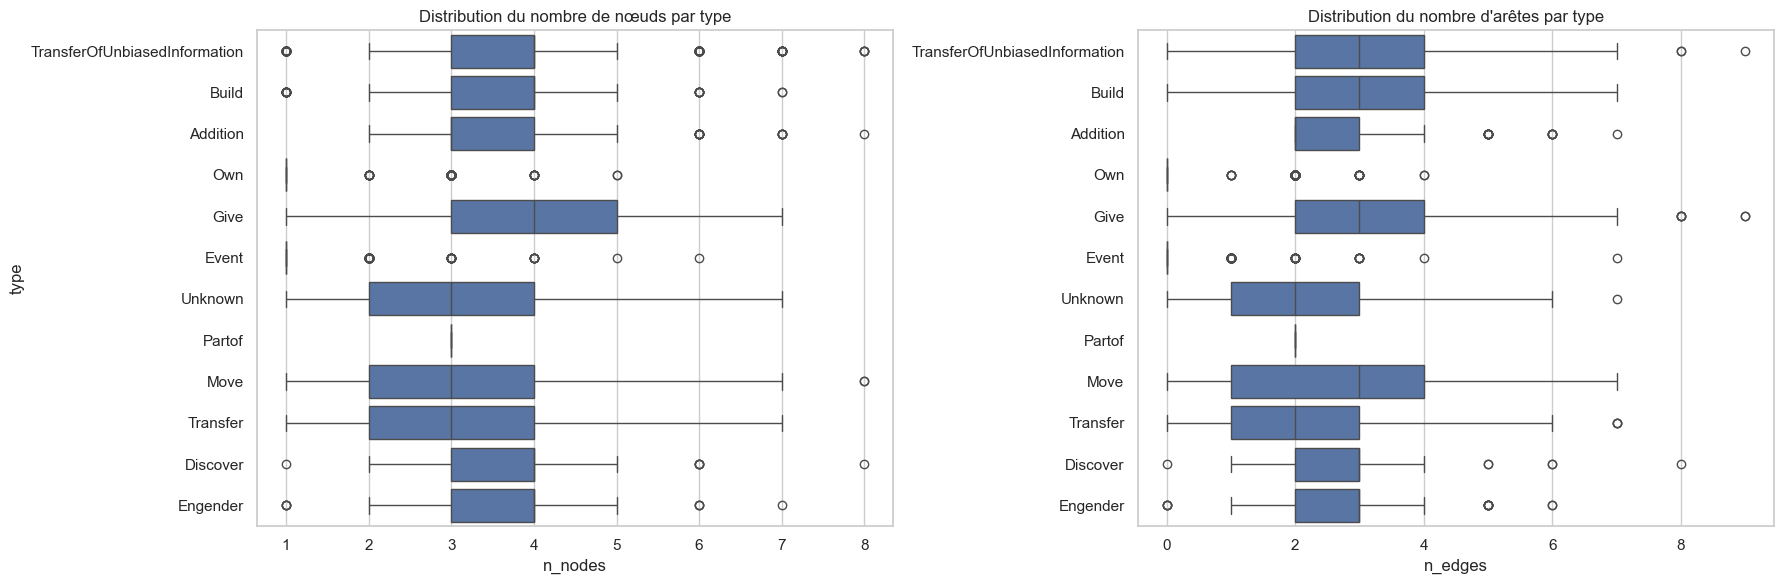

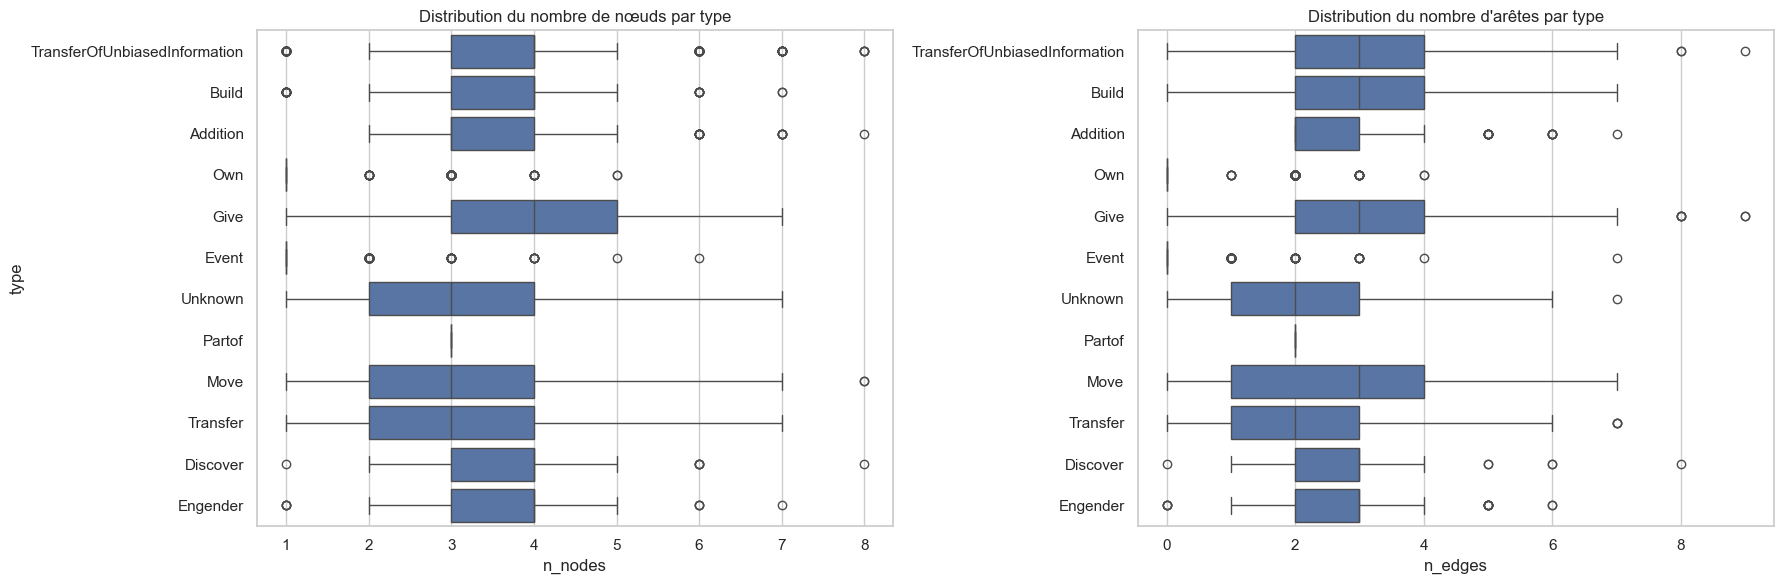

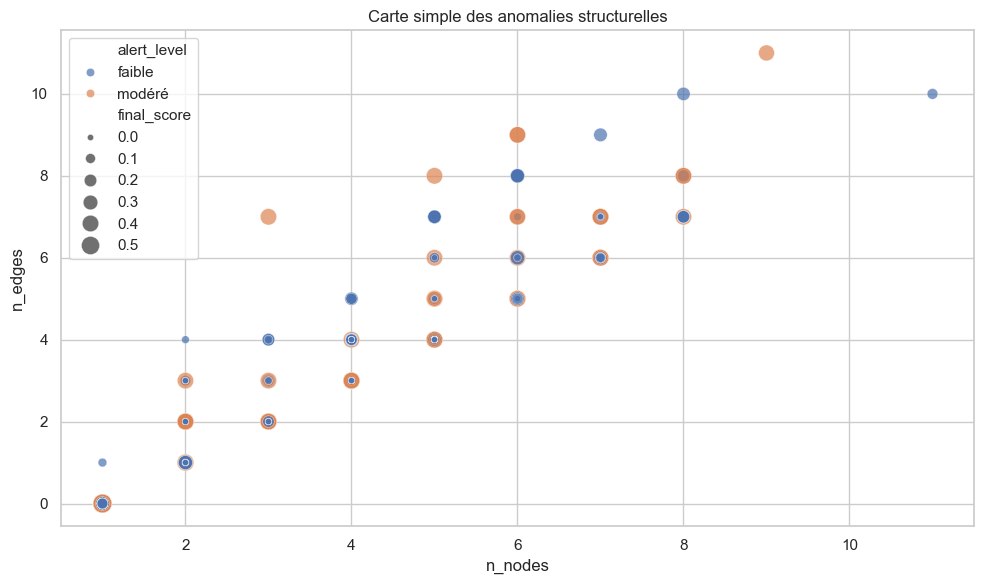

In [18]:
# On garde les types les plus fréquents pour ne pas surcharger la vue
top_types = struct_df["type_last"].value_counts().head(12).index
plot_df = struct_df[struct_df["type_last"].isin(top_types)].copy()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.boxplot(data=plot_df, x="n_nodes", y="type_last", ax=axes[0])
axes[0].set_title("Distribution du nombre de nœuds par type")
axes[0].set_xlabel("n_nodes")
axes[0].set_ylabel("type")

sns.boxplot(data=plot_df, x="n_edges", y="type_last", ax=axes[1])
axes[1].set_title("Distribution du nombre d'arêtes par type")
axes[1].set_xlabel("n_edges")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=struct_df,
    x="n_nodes",
    y="n_edges",
    hue="alert_level",
    size="final_score",
    sizes=(20, 180),
    alpha=0.7
)
plt.title("Carte simple des anomalies structurelles")
plt.xlabel("n_nodes")
plt.ylabel("n_edges")
plt.tight_layout()
plt.show()

In [19]:
def inspect_event_structure(event_id):
    row = suspects_df.loc[suspects_df["event_id"] == event_id]
    if row.empty:
        print("event_id introuvable")
        return

    row = row.iloc[0]

    print("=" * 120)
    print("event_id     :", row["event_id"])
    print("type         :", row["type"])
    print("niveau       :", row["alert_level"])
    print("score final  :", round(row["final_score"], 3))
    print("n_nodes      :", row["n_nodes"])
    print("n_edges      :", row["n_edges"])
    print("isolated     :", row["n_isolated_nodes"])
    print("components   :", row["n_weak_components"])
    print("orphan_edges :", row["n_orphan_edges"])
    print("motif        :", row["reason"])
    print("context      :", row["context_short"])
    print("-" * 120)

    print("NODES")
    display(
        nodes_df.loc[nodes_df["event_id"] == event_id, ["node_id", "form", "node_label"]]
        .reset_index(drop=True)
    )

    print("EDGES")
    display(
        edges_df.loc[edges_df["event_id"] == event_id, ["edge_id", "edge_type", "source", "target"]]
        .reset_index(drop=True)
    )

In [23]:
inspect_event_structure(suspects_df.iloc[2]["event_id"])

event_id     : 6998aed96736db9dc26e6319
type         : Thing/Abstract/Event/Attend
niveau       : modéré
score final  : 0.533
n_nodes      : 1
n_edges      : 0
isolated     : 1
components   : 1
orphan_edges : 0.0
motif        : 0 arête alors que la moyenne de référence est 3.63 | événement réduit à un seul nœud | nombre de nœuds atypique (1 vs moyenne réf. 4.44) | ratio arêtes / nœuds atypique (0.0 vs moyenne réf. 0.76) | nombre de nœuds isolés atypique (1 vs moyenne réf. 0.04)
context      : mis de conduire et le bilan de compétences, plafond pour la formation de langue, augmentation de la participation salariale de 100 à 150euro...
------------------------------------------------------------------------------------------------------------------------
NODES


event_id     : 6998aed96736db9dc26e6319
type         : Thing/Abstract/Event/Attend
niveau       : modéré
score final  : 0.533
n_nodes      : 1
n_edges      : 0
isolated     : 1
components   : 1
orphan_edges : 0.0
motif        : 0 arête alors que la moyenne de référence est 3.63 | événement réduit à un seul nœud | nombre de nœuds atypique (1 vs moyenne réf. 4.44) | ratio arêtes / nœuds atypique (0.0 vs moyenne réf. 0.76) | nombre de nœuds isolés atypique (1 vs moyenne réf. 0.04)
context      : mis de conduire et le bilan de compétences, plafond pour la formation de langue, augmentation de la participation salariale de 100 à 150euro...
------------------------------------------------------------------------------------------------------------------------
NODES


,node_id,form,node_label
0,12063354,participation,Thing/Abstract/Event/Attend


EDGES


,edge_id,edge_type,source,target
